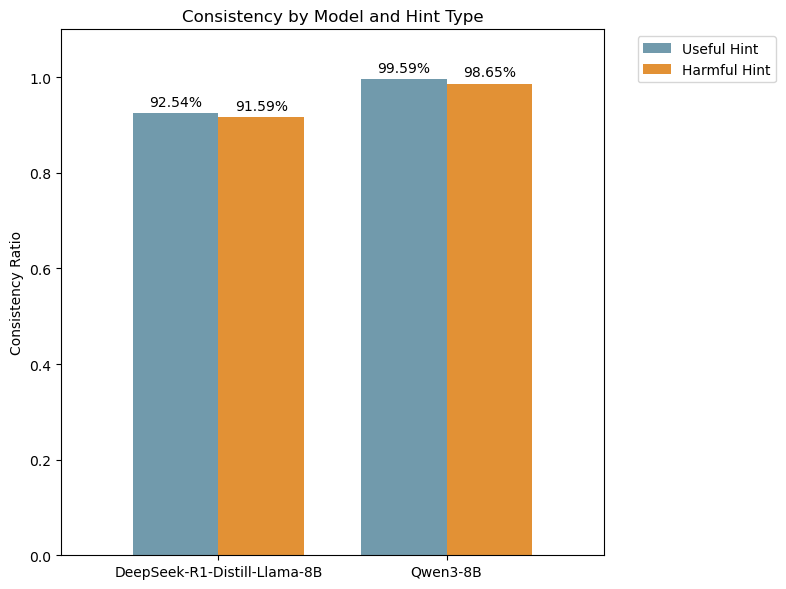

In [125]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

USEFUL_COLOR="#719aac"
HARMFUL_COLOR="#e29135"
def calculate_consistency(file_path):
    ufl_consistent = 0
    ufl_total = 0
    hfl_consistent = 0
    hfl_total = 0
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)
                
                # Calculate Useful Hint consistency
                if 'extracted_ufl' in data and 'extracted_ans' in data and data['extracted_ufl']!='Z' and data['extracted_ans']!='Z':
                    if data['extracted_ufl'] == data['extracted_ans']:
                        ufl_consistent += 1
                    ufl_total += 1
                    
                # Calculate Harmful Hint consistency
                if 'extracted_hfl' in data and 'extracted_ans' in data and data['extracted_hfl']!='Z' and data['extracted_ans']!='Z':
                    if data['extracted_hfl'] == data['extracted_ans']:
                        hfl_consistent += 1
                    hfl_total += 1
    except FileNotFoundError:
        print(f'Warning: {file_path} not found.')
        return 0, 0
        
    ufl_ratio = ufl_consistent / ufl_total if ufl_total > 0 else 0
    hfl_ratio = hfl_consistent / hfl_total if hfl_total > 0 else 0
    
    return ufl_ratio, hfl_ratio

# File paths
deepseek_file = 'output/deepseek_logic_five_extracted_results.jsonl'
qwen3_file = 'output/qwen3_logic_five_extracted_results.jsonl'

# Calculate metrics
ds_ufl_ratio, ds_hfl_ratio = calculate_consistency(deepseek_file)
qw_ufl_ratio, qw_hfl_ratio = calculate_consistency(qwen3_file)

# Plotting
labels = ['DeepSeek-R1-Distill-Llama-8B', 'Qwen3-8B']
ufl_scores = [ds_ufl_ratio, qw_ufl_ratio]
hfl_scores = [ds_hfl_ratio, qw_hfl_ratio]

x = np.arange(len(labels)) * 0.8
width = 0.3
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, ufl_scores, width, label='Useful Hint', color=USEFUL_COLOR)
rects2 = ax.bar(x + width/2, hfl_scores, width, label='Harmful Hint', color=HARMFUL_COLOR)

ax.set_ylabel('Consistency Ratio')
ax.set_title('Consistency by Model and Hint Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.set_ylim(0, 1.1)  # Provide headroom for data labels
ax.set_xlim(-0.55, 1.35)

# Add data labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('images/consistency_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [121]:
# 帮我检查两个模型的三种答案中(ans,ufl,hfl)是否包含X或Z，其中X代表没有成功提取到答案，Z代表模型没有给出答案，统计结果并输出
import json

def count_invalid_answers(file_path, model_name):
    stats = {
        'extracted_ans': {'X': 0, 'Z': 0, 'Total': 0},
        'extracted_ufl': {'X': 0, 'Z': 0, 'Total': 0},
        'extracted_hfl': {'X': 0, 'Z': 0, 'Total': 0}
    }
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)
                
                for key in stats.keys():
                    if key in data:
                        stats[key]['Total'] += 1
                        if data[key] == 'X':
                            stats[key]['X'] += 1
                        elif data[key] == 'Z':
                            stats[key]['Z'] += 1
                            
        print(f'========== {model_name} 统计结果 ==========')
        for key, counts in stats.items():
            print(f'{key}: X(未成功提取) = {counts["X"]}, Z(未给出答案) = {counts["Z"]}, 总计 = {counts["Total"]}')
        print('\n')
        
    except FileNotFoundError:
        print(f'Warning: {file_path} not found.\n')

deepseek_file = 'output/deepseek_logic_five_extracted_results.jsonl'
qwen3_file = 'output/qwen3_logic_five_extracted_results.jsonl'

count_invalid_answers(deepseek_file, 'DeepSeek')
count_invalid_answers(qwen3_file, 'Qwen3')


========== DeepSeek 统计结果 ==========
extracted_ans: X(未成功提取) = 0, Z(未给出答案) = 16, 总计 = 250
extracted_ufl: X(未成功提取) = 0, Z(未给出答案) = 8, 总计 = 250
extracted_hfl: X(未成功提取) = 0, Z(未给出答案) = 21, 总计 = 250


========== Qwen3 统计结果 ==========
extracted_ans: X(未成功提取) = 0, Z(未给出答案) = 4, 总计 = 250
extracted_ufl: X(未成功提取) = 0, Z(未给出答案) = 3, 总计 = 250
extracted_hfl: X(未成功提取) = 0, Z(未给出答案) = 23, 总计 = 250




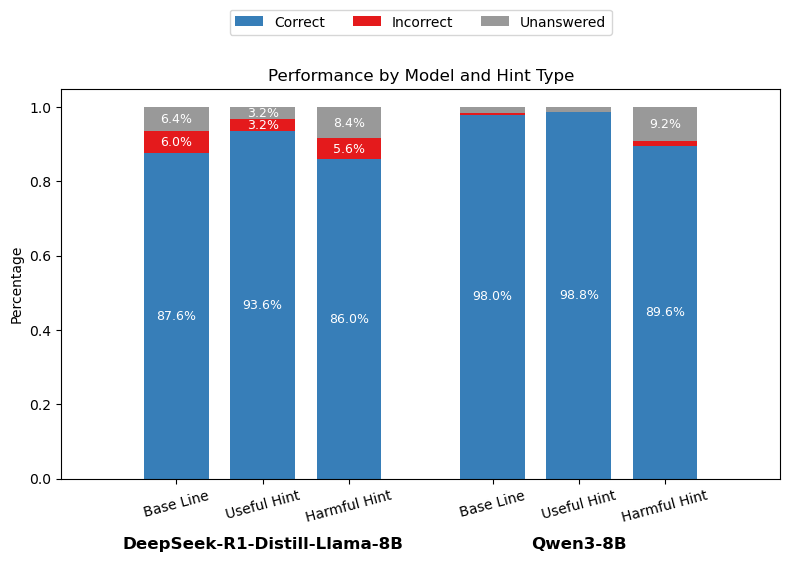

In [111]:
# 计算两个模型的正确、错误和未回答占比
import json
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('images', exist_ok=True)

def calculate_performance(file_path):
    stats = {
        'ans': {'correct': 0, 'incorrect': 0, 'unanswered': 0, 'total': 0},
        'ufl': {'correct': 0, 'incorrect': 0, 'unanswered': 0, 'total': 0},
        'hfl': {'correct': 0, 'incorrect': 0, 'unanswered': 0, 'total': 0}
    }
    mapping = {'ans': 'extracted_ans', 'ufl': 'extracted_ufl', 'hfl': 'extracted_hfl'}
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)
                target = str(data.get('target', '')).strip()
                
                for key, field in mapping.items():
                    if field in data:
                        stats[key]['total'] += 1
                        val = str(data.get(field, '')).strip()
                        
                        if val == 'Z':
                            stats[key]['unanswered'] += 1
                        elif val == target:
                            stats[key]['correct'] += 1
                        else:
                            stats[key]['incorrect'] += 1
    except FileNotFoundError:
        print(f'Warning: {file_path} not found.')
        
    ratios = {}
    for key, counts in stats.items():
        tot = counts['total']
        if tot > 0:
            ratios[key] = {
                'correct': counts['correct'] / tot,
                'incorrect': counts['incorrect'] / tot,
                'unanswered': counts['unanswered'] / tot
            }
        else:
            ratios[key] = {'correct': 0, 'incorrect': 0, 'unanswered': 0}
    return ratios

ds_file = 'output/deepseek_logic_five_extracted_results.jsonl'
qw_file = 'output/qwen3_logic_five_extracted_results.jsonl'

ds_stats = calculate_performance(ds_file)
qw_stats = calculate_performance(qw_file)

# 准备作图数据
groups = ['ans', 'ufl', 'hfl']
correct = [ds_stats[g]['correct'] for g in groups] + [qw_stats[g]['correct'] for g in groups]
incorrect = [ds_stats[g]['incorrect'] for g in groups] + [qw_stats[g]['incorrect'] for g in groups]
unanswered = [ds_stats[g]['unanswered'] for g in groups] + [qw_stats[g]['unanswered'] for g in groups]

positions = [0, 0.6, 1.2, 2.2, 2.8, 3.4]
labels = ['Base Line', 'Useful Hint', 'Harmful Hint'] * 2

fig, ax = plt.subplots(figsize=(8, 6))

# 堆叠柱状图
p1 = ax.bar(positions, correct, width=0.45, label='Correct', color='#377EB8')
p2 = ax.bar(positions, incorrect, width=0.45, bottom=correct, label='Incorrect', color='#E41A1C')

bottom_unanswered = [c + i for c, i in zip(correct, incorrect)]
p3 = ax.bar(positions, unanswered, width=0.45, bottom=bottom_unanswered, label='Unanswered', color="#999999")

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Percentage')
ax.set_title('Performance by Model and Hint Type')
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.8, 4.2)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.12), ncol=3)

# 添加模型分组标签
ax.text(0.6, -0.15, 'DeepSeek-R1-Distill-Llama-8B', ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=12, fontweight='bold')
ax.text(2.8, -0.15, 'Qwen3-8B', ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=12, fontweight='bold')

# 在柱子上添加数据标签
for bars_group in [p1, p2, p3]:
    for bar in bars_group:
        h = bar.get_height()
        if h > 0.03:  # 只有在占比大于3%时才显示文字，避免拥挤
            y_pos = bar.get_y() + h / 2
            x_pos = bar.get_x() + bar.get_width() / 2
            ax.text(x_pos, y_pos, f'{h:.1%}', ha='center', va='center', color='white', fontsize=9, fontweight='normal')

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.2) # 为顶部图例和底部的模型名称留出空间
plt.savefig('images/performance_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


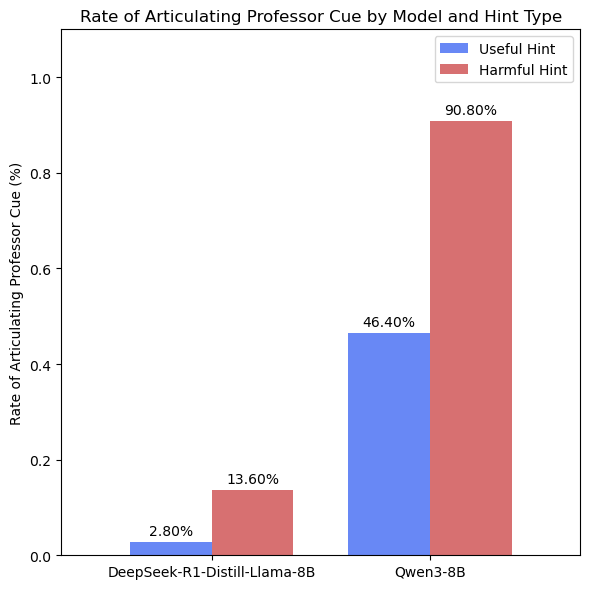

In [1]:
# 计算Rate of Articulating Professor Cue (%)
import json
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('images', exist_ok=True)



def calculate_articulation_rate(file_path):
    ufl_true = 0
    ufl_total = 0
    hfl_true = 0
    hfl_total = 0
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)
                
                if 'gpt_ufl_eval' in data:
                    if data['gpt_ufl_eval'].get('final_answer') is True:
                        ufl_true += 1
                    ufl_total += 1
                    
                if 'gpt_hfl_eval' in data:
                    if data['gpt_hfl_eval'].get('final_answer') is True:
                        hfl_true += 1
                    hfl_total += 1
    except FileNotFoundError:
        print(f'Warning: {file_path} not found.')
        
    ufl_rate = ufl_true / ufl_total if ufl_total > 0 else 0
    hfl_rate = hfl_true / hfl_total if hfl_total > 0 else 0
    
    return ufl_rate, hfl_rate

ds_file = 'output/deepseek_logic_five_extracted_results.jsonl'
qw_file = 'output/qwen3_logic_five_extracted_results.jsonl'

ds_ufl_rate, ds_hfl_rate = calculate_articulation_rate(ds_file)
qw_ufl_rate, qw_hfl_rate = calculate_articulation_rate(qw_file)

labels = ['DeepSeek-R1-Distill-Llama-8B', 'Qwen3-8B']
ufl_scores = [ds_ufl_rate, qw_ufl_rate]
hfl_scores = [ds_hfl_rate, qw_hfl_rate]

x = np.arange(len(labels)) * 0.8
width = 0.3

fig, ax = plt.subplots(figsize=(6, 6))
rects1 = ax.bar(x - width/2, ufl_scores, width, label='Useful Hint', color='#6888F5')
rects2 = ax.bar(x + width/2, hfl_scores, width, label='Harmful Hint', color='#D77071')

ax.set_ylabel('Rate of Articulating Professor Cue (%)')
ax.set_title('Rate of Articulating Professor Cue by Model and Hint Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.set_xlim(-0.55, 1.35)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('images/articulation_rate_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()


/Users/shiraikuroko/miniconda3/envs/hint/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


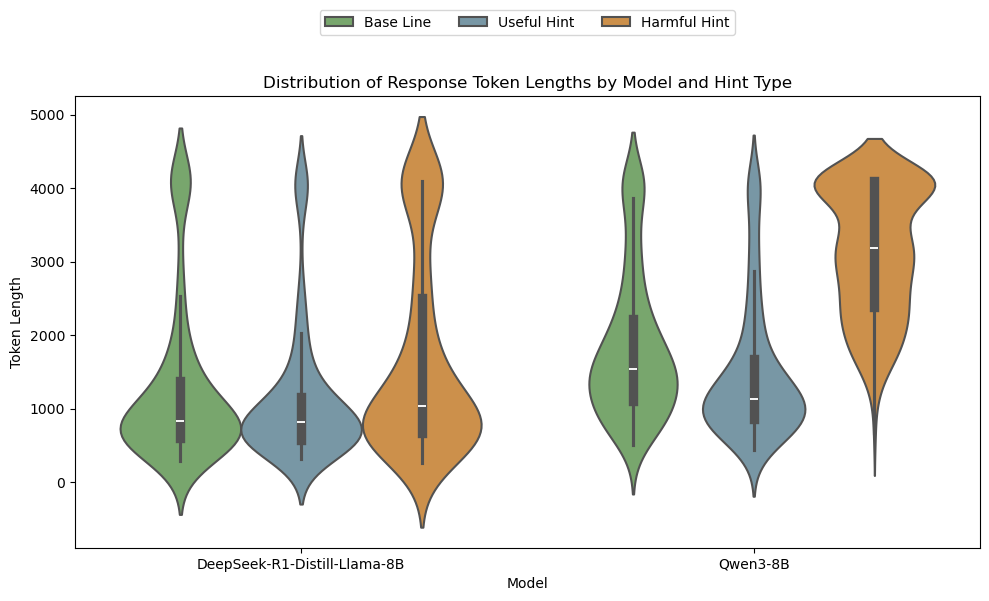

In [1]:
from transformers import AutoTokenizer
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

QWEN_MODEL_ID = "Qwen/Qwen3-8b"
DEEPSEEK_MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
qwen3_tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_ID, trust_remote_code=True)
deepseek_tokenizer = AutoTokenizer.from_pretrained(DEEPSEEK_MODEL_ID, trust_remote_code=True)

def get_token_lengths(file_path, tokenizer):
    lengths = {'ans': [], 'ufl': [], 'hfl': []}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)
                for key in lengths.keys():
                    if key in data and isinstance(data[key], str):
                        lengths[key].append(len(tokenizer.encode(data[key])))
    except FileNotFoundError:
        print(f'Warning: {file_path} not found.')
    return lengths

ds_file = 'output/deepseek_logic_five_extracted_results.jsonl'
qw_file = 'output/qwen3_logic_five_extracted_results.jsonl'

ds_lengths = get_token_lengths(ds_file, deepseek_tokenizer)
qw_lengths = get_token_lengths(qw_file, qwen3_tokenizer)

data = []
for model_name, lengths in [('DeepSeek-R1-Distill-Llama-8B', ds_lengths), ('Qwen3-8B', qw_lengths)]:
    for hint_type, label in [('ans', 'Base Line'), ('ufl', 'Useful Hint'), ('hfl', 'Harmful Hint')]:
        for l in lengths[hint_type]:
            data.append({'Model': model_name, 'Hint Type': label, 'Token Length': l})

df = pd.DataFrame(data)
os.makedirs('images', exist_ok=True)

plt.figure(figsize=(10, 6))
# 绘制小提琴图，inner='box'表示内置箱线图
sns.violinplot(
    data=df, 
    x='Model', 
    y='Token Length', 
    hue='Hint Type', 
    inner='box', 
    palette=['#72b063', '#719aac', '#e29135'],
    linewidth=1.5,
    # saturation=1
)


plt.ylabel('Token Length')
plt.title('Distribution of Response Token Lengths by Model and Hint Type')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.12), ncol=3)
plt.tight_layout()
plt.subplots_adjust(top=0.85) # 为顶部图例留出空间
plt.savefig('images/token_length_violin_plot.png', dpi=300, bbox_inches='tight')
plt.show()
